# **Teen Mental Health Analysis**

In [48]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

## 1. Load the given Teen Mental Health Dataset and display the first 10 rows. List all numerical and categorical variables separately. Check the data types of all columns and interpret whether any column requires type conversion

In [49]:
df = pd.read_csv("Teen_Mental_Health.csv")
print("Files loaded.")
print(f"DF shape   : {df.shape}")

Files loaded.
DF shape   : (1200, 13)


In [50]:
df.head(10)

,age,gender,daily_social_media_hours,platform_usage,sleep_hours,screen_time_before_sleep,academic_performance,physical_activity,social_interaction_level,stress_level,anxiety_level,addiction_level,depression_label
0,14.0,NaN,7.9,Instagram,7.4,2.9,3.01,1.5,low,2.0,NaN,1.0,0.0
1,19.0,female,1.9,TikTok,8.0,2.9,3.22,0.8,NaN,8.0,1.0,10.0,0.0
2,17.0,female,1.3,Instagram,7.6,0.5,3.92,0.0,high,2.0,4.0,2.0,0.0
3,15.0,male,7.4,TikTok,6.9,1.6,NaN,0.8,NaN,1.0,7.0,9.0,NaN
4,15.0,female,NaN,Both,4.9,3.0,2.37,1.4,NaN,3.0,5.0,2.0,0.0
5,NaN,female,7.4,Both,4.4,2.4,2.63,0.6,high,3.0,5.0,7.0,0.0
6,18.0,female,2.5,Instagram,6.4,2.4,2.63,0.7,low,2.0,2.0,5.0,0.0
7,16.0,male,4.0,Both,4.2,0.5,2.40,NaN,low,6.0,10.0,NaN,0.0
8,19.0,female,3.3,TikTok,5.0,2.1,NaN,0.9,high,1.0,10.0,9.0,0.0
9,15.0,male,1.9,TikTok,4.9,1.5,3.77,1.1,high,1.0,1.0,4.0,0.0


In [51]:
df.sample(10)

,age,gender,daily_social_media_hours,platform_usage,sleep_hours,screen_time_before_sleep,academic_performance,physical_activity,social_interaction_level,stress_level,anxiety_level,addiction_level,depression_label
163,15.0,female,7.8,TikTok,5.3,0.5,2.32,0.8,low,8.0,9.0,3.0,1.0
543,17.0,female,NaN,NaN,8.6,1.9,3.33,1.1,NaN,1.0,NaN,8.0,NaN
1071,NaN,female,NaN,TikTok,9.0,1.5,3.37,1.9,low,4.0,3.0,1.0,0.0
491,NaN,female,5.7,TikTok,6.2,0.5,3.98,1.7,medium,7.0,6.0,3.0,0.0
860,NaN,male,3.5,TikTok,4.5,2.7,2.47,1.4,low,1.0,5.0,10.0,0.0
856,19.0,male,4.8,Both,7.5,1.0,2.68,1.5,NaN,9.0,4.0,6.0,0.0
566,14.0,NaN,NaN,TikTok,7.9,2.9,2.54,0.7,NaN,5.0,8.0,7.0,0.0
609,17.0,male,6.4,TikTok,8.6,2.3,NaN,1.3,low,9.0,10.0,5.0,0.0
252,13.0,male,5.6,NaN,4.6,1.9,2.54,NaN,low,5.0,5.0,6.0,0.0
794,17.0,male,4.0,Both,8.5,1.0,2.16,0.1,NaN,1.0,7.0,5.0,0.0


In [52]:
numerical_vars = df.select_dtypes(include=["number"]).columns.tolist()
categorical_vars = df.select_dtypes(exclude=["number"]).columns.tolist()

print("Numerical variables:")
print(numerical_vars)

print("\nCategorical variables:")
print(categorical_vars)

Numerical variables:
['age', 'daily_social_media_hours', 'sleep_hours', 'screen_time_before_sleep', 'academic_performance', 'physical_activity', 'stress_level', 'anxiety_level', 'addiction_level', 'depression_label']

Categorical variables:
['gender', 'platform_usage', 'social_interaction_level']


In [53]:
print(df.dtypes)

age                         float64
gender                          str
daily_social_media_hours    float64
platform_usage                  str
sleep_hours                 float64
screen_time_before_sleep    float64
academic_performance        float64
physical_activity           float64
social_interaction_level        str
stress_level                float64
anxiety_level               float64
addiction_level             float64
depression_label            float64
dtype: object


## 2a. Generate descriptive statistics for all numerical variables.Which variable shows the highest variation?

In [54]:
df.describe()

,age,daily_social_media_hours,sleep_hours,screen_time_before_sleep,academic_performance,physical_activity,stress_level,anxiety_level,addiction_level,depression_label
count,1105.000000,1056.000000,1008.000000,1140.000000,1080.000000,1092.000000,1092.000000,1092.000000,1128.000000,1008.000000
mean,15.901357,4.544129,6.443155,1.735965,2.986148,1.016392,5.454212,5.608974,5.572695,0.025794
std,2.016294,2.027443,1.457104,0.717721,0.578481,0.581912,2.898641,2.851348,2.836578,0.158598
min,13.000000,1.000000,4.000000,0.500000,2.000000,0.000000,1.000000,1.000000,1.000000,0.000000
25%,14.000000,2.800000,5.100000,1.100000,2.490000,0.500000,3.000000,3.000000,3.000000,0.000000
50%,16.000000,4.500000,6.400000,1.700000,2.980000,1.000000,5.000000,6.000000,6.000000,0.000000
75%,18.000000,6.300000,7.700000,2.325000,3.480000,1.500000,8.000000,8.000000,8.000000,0.000000
max,19.000000,8.000000,9.000000,3.000000,4.000000,2.000000,10.000000,10.000000,10.000000,1.000000


As we can infer, stress_level, anxiety_level and addiction level have the highest variation with their standard deviation being 2.85

## 2b. Compare the mean and median of daily social media hours and sleep hours. What does the difference indicate about the distribution and skewness of these variables?

In [71]:
df['daily_social_media_hours'].median()

np.float64(4.5)

In [73]:
df['daily_social_media_hours'].mean()

np.float64(4.538833333333333)

In [72]:
df['sleep_hours'].median()

np.float64(6.4)

In [74]:
df['sleep_hours'].mean()

np.float64(6.43625)

Mean of daily social media hours is 4.5 and the median is 4.5 as well indication normal distribution and no skweness. The mean and median of sleep hours is 6.4 which also suggests normal distribution with no skweness as Mean=Median

## 3a. Identify all variables containing missing values. Calculate the number and percentage of missing values in each column.

In [55]:
missing_count= df.isnull().sum()
missing_count

age                          95
gender                      228
daily_social_media_hours    144
platform_usage              168
sleep_hours                 192
screen_time_before_sleep     60
academic_performance        120
physical_activity           108
social_interaction_level    168
stress_level                108
anxiety_level               108
addiction_level              72
depression_label            192
dtype: int64

In [56]:
missing_percent=(missing_count/len(df))*100
missing_percent

age                          7.916667
gender                      19.000000
daily_social_media_hours    12.000000
platform_usage              14.000000
sleep_hours                 16.000000
screen_time_before_sleep     5.000000
academic_performance        10.000000
physical_activity            9.000000
social_interaction_level    14.000000
stress_level                 9.000000
anxiety_level                9.000000
addiction_level              6.000000
depression_label            16.000000
dtype: float64

## 3b. Suggest suitable imputation techniques for missing values in daily social media hours, sleep hours, and screen time before sleep.

For missing values in daily social media hours and sleep hours, the percentage of missing values is >5% thus we cannot use mode imputation. The best for these colums woud be median imputation. We can do both mode and median imputation for screen time before seep but i will proceed with the ideal method of Median imputation.

In [57]:
cols_to_impute = [
    "daily_social_media_hours",
    "sleep_hours",
    "screen_time_before_sleep"
]

for col in cols_to_impute:
    df[col] = df[col].fillna(df[col].median())

print(df[cols_to_impute].isnull().sum())

daily_social_media_hours    0
sleep_hours                 0
screen_time_before_sleep    0
dtype: int64


## 3c. Suggest suitable imputation techniques for missing values in stress level, anxiety level, and addiction level.

We favour median imputation. As its target value and missing percentage >5%.

In [58]:
cols_to_impute_2 = ["stress_level", "anxiety_level", "addiction_level"]

for col in cols_to_impute_2:
    df[col] = df[col].fillna(df[col].median())

print(df[cols_to_impute_2].isnull().sum())

stress_level       0
anxiety_level      0
addiction_level    0
dtype: int64


Handling missing values of all other colums

In [60]:

remaining_cat_cols = [col for col in df.select_dtypes(exclude=["number"]).columns if df[col].isna().any()]
for col in remaining_cat_cols:
    df[col] = df[col].fillna(df[col].mode(dropna=True)[0])

remaining_num_cols = [col for col in df.select_dtypes(include=["number"]).columns if df[col].isna().any()]
for col in remaining_num_cols:
    if col == "depression_label":
        df[col] = df[col].fillna(df[col].mode(dropna=True)[0])
    else:
        df[col] = df[col].fillna(df[col].median())

print(df.isnull().sum())

age                         0
gender                      0
daily_social_media_hours    0
platform_usage              0
sleep_hours                 0
screen_time_before_sleep    0
academic_performance        0
physical_activity           0
social_interaction_level    0
stress_level                0
anxiety_level               0
addiction_level             0
depression_label            0
dtype: int64


## 3d. Explain how missingness in mental health indicators such as anxiety level could potentially be MAR or MNAR.

Mental Health indicators are MAR (Missing at Random). There was no such result to direct that there is any relation with other features. There would have been missing values in case a student identifies that they dont have it but in this case its a questionnaire with options to select from 1-10 (An ordinal scale)

## 4a. Plot charts showing the distribution of gender, platform usage, and depression label.


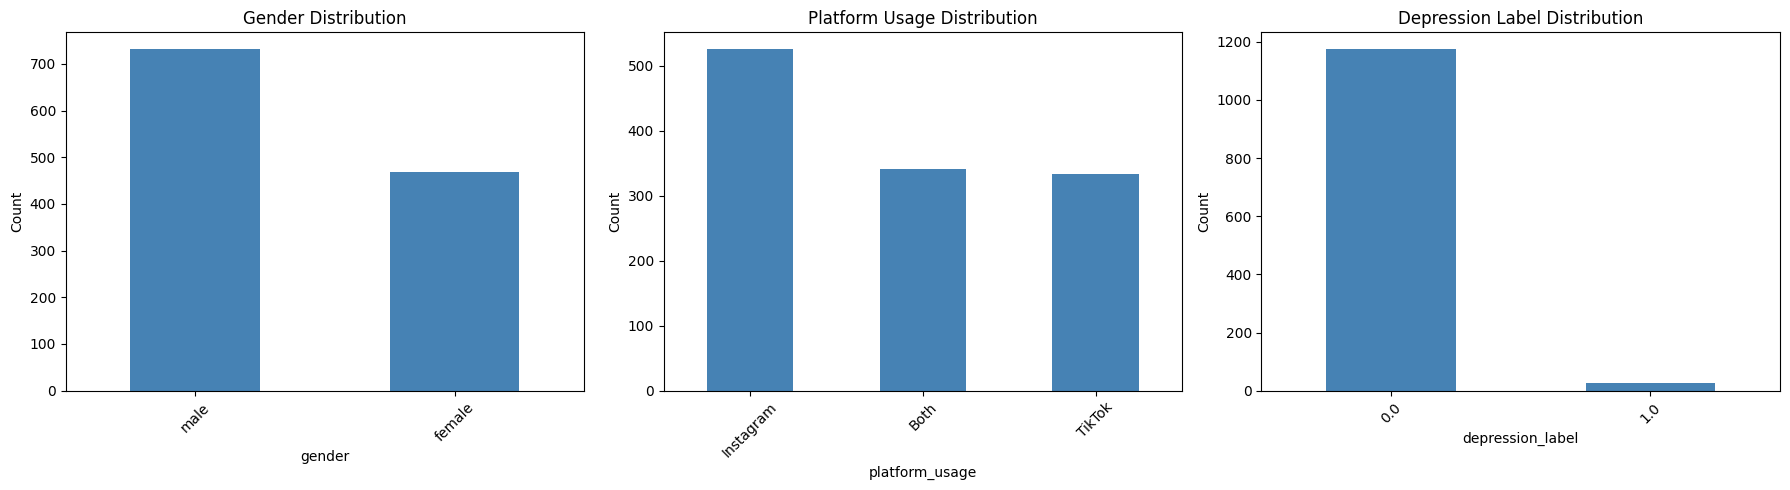

In [61]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
plot_cols = ["gender", "platform_usage", "depression_label"]
titles = ["Gender Distribution", "Platform Usage Distribution", "Depression Label Distribution"]
for ax, col, title in zip(axes, plot_cols, titles):
    df[col].astype(str).fillna("Missing").value_counts().plot(kind="bar", ax=ax, color="steelblue")
    ax.set_title(title)
    ax.set_xlabel(col)
    ax.set_ylabel("Count")
    ax.tick_params(axis="x", rotation=45)
plt.tight_layout()
plt.show()

## 4b. Plot boxplots of stress level, anxiety level, and addiction level grouped by depression label.

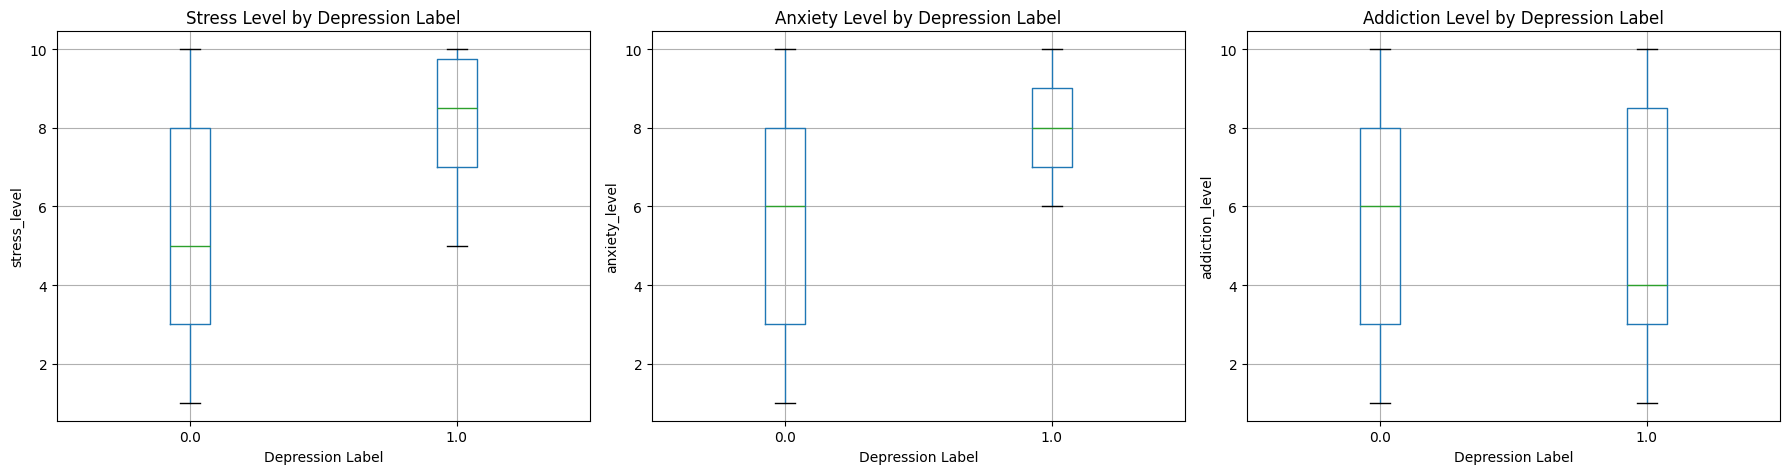

In [62]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
boxplot_cols = ["stress_level", "anxiety_level", "addiction_level"]
titles = ["Stress Level by Depression Label", "Anxiety Level by Depression Label", "Addiction Level by Depression Label"]
for ax, col, title in zip(axes, boxplot_cols, titles):
    df.boxplot(column=col, by="depression_label", ax=ax)
    ax.set_title(title)
    ax.set_xlabel("Depression Label")
    ax.set_ylabel(col)
plt.suptitle("")
plt.tight_layout()
plt.show()

## 4c. Plot scatter plots between daily social media hours and stress level, and sleep hours and anxiety level.

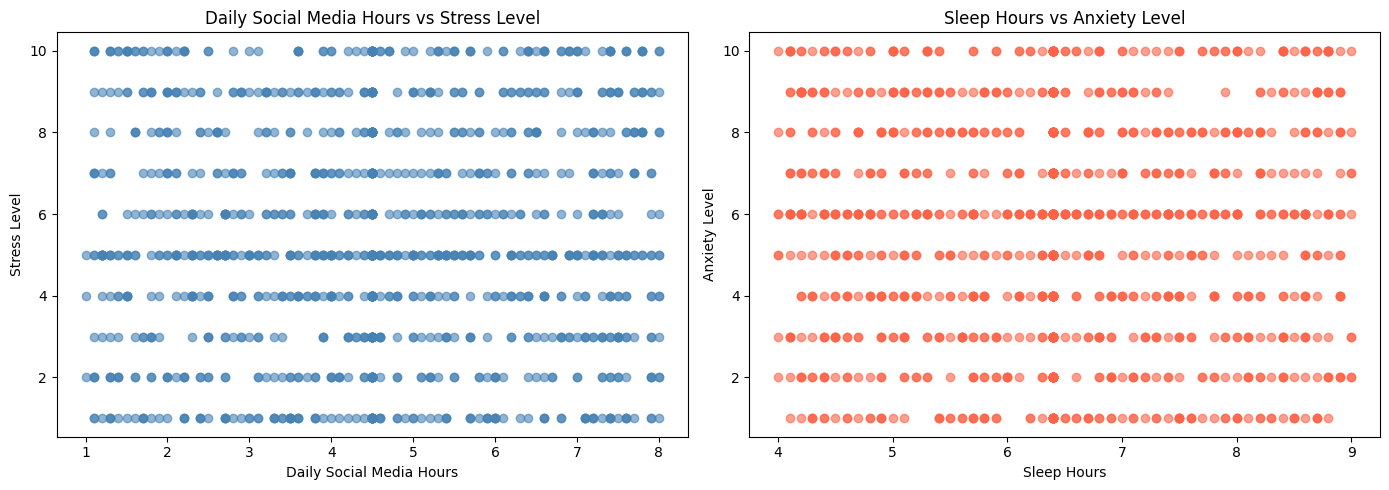

In [63]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].scatter(df["daily_social_media_hours"], df["stress_level"], alpha=0.6, color="steelblue")
axes[0].set_title("Daily Social Media Hours vs Stress Level")
axes[0].set_xlabel("Daily Social Media Hours")
axes[0].set_ylabel("Stress Level")
axes[1].scatter(df["sleep_hours"], df["anxiety_level"], alpha=0.6, color="tomato")
axes[1].set_title("Sleep Hours vs Anxiety Level")
axes[1].set_xlabel("Sleep Hours")
axes[1].set_ylabel("Anxiety Level")
plt.tight_layout()
plt.show()

## 4d. Interpret any three charts and explain what they reveal about teen mental health patterns

- The gender distribution chart shows how the sample is distributed across gender categories. Where there are mostly males considered in this study.
- The boxplots for stress, anxiety, and addiction by depression label suggest that higher depression groups tend to have higher stress and anxiety scores, and often slightly higher addiction scores as well. This points to a clear association between depression and poorer mental health indicators.
- The scatter plots show a weak positive trend between daily social media hours and stress level, while sleep hours and anxiety level show a weak negative trend i.e, more screen use is not a strong predictor by itself, but shorter sleep appears more consistently linked to worse mental health outcomes.

## 5. Perform correlation analysis on the numerical variables by creating a correlation matrix. Identify the strength and direction of correlations, and interpret the relationships among daily social media hours, sleep hours, stress level, anxiety level, addiction level, and academic performance. Further, explain why categorical variables should not be directly included in correlation analysis without appropriate encoding.

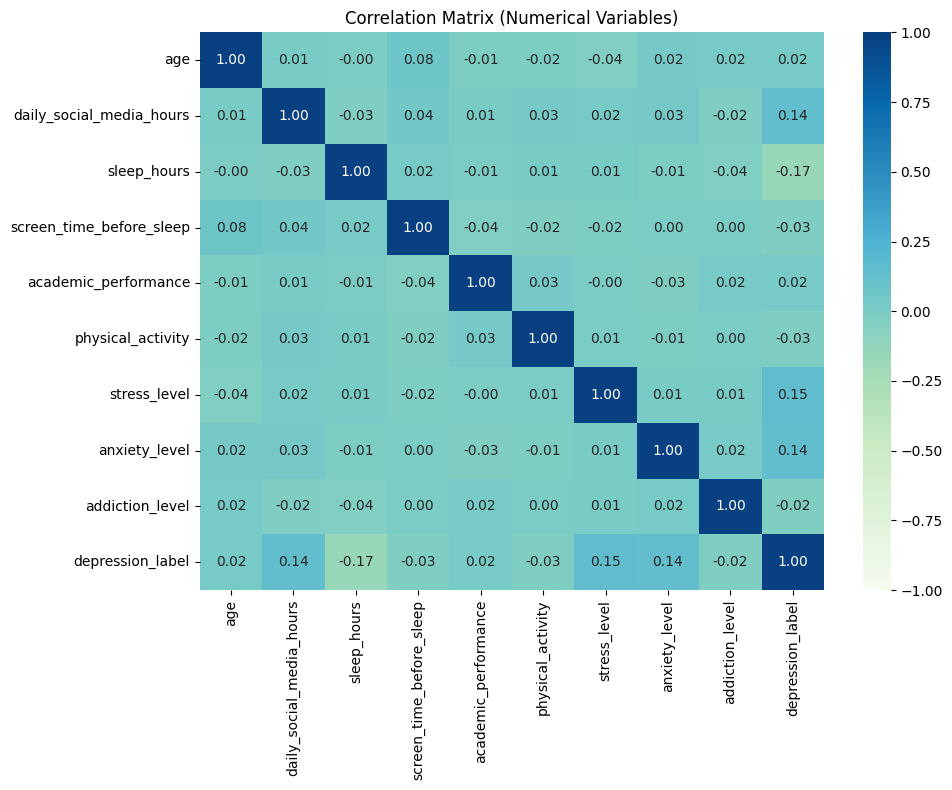

In [76]:
import seaborn as sns
corr = df[numerical_vars].corr()
plt.figure(figsize=(10, 8))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="GnBu", vmin=-1, vmax=1)
plt.title("Correlation Matrix (Numerical Variables)")
plt.tight_layout()
plt.show()

In [68]:
corr_pairs = corr.abs().where(~np.eye(corr.shape[0], dtype=bool)).stack().sort_values(ascending=False)
top_pairs = corr_pairs[~corr_pairs.index.duplicated()].head(10)

print("\nTop correlated variable pairs:")
for (v1, v2), val in top_pairs.items():
    actual = corr.loc[v1, v2]
    direction = "positive" if actual > 0 else "negative"
    print(f"{v1} with {v2}: {actual:.2f} ({direction})")


Top correlated variable pairs:
sleep_hours with depression_label: -0.17 (negative)
depression_label with sleep_hours: -0.17 (negative)
depression_label with stress_level: 0.15 (positive)
stress_level with depression_label: 0.15 (positive)
depression_label with anxiety_level: 0.14 (positive)
anxiety_level with depression_label: 0.14 (positive)
depression_label with daily_social_media_hours: 0.14 (positive)
daily_social_media_hours with depression_label: 0.14 (positive)
screen_time_before_sleep with age: 0.08 (positive)
age with screen_time_before_sleep: 0.08 (positive)


## 6a. Use the IQR method to identify outliers in daily_social_media_hours, sleep hours, stress level, and anxiety_level.

In [70]:
iqr_cols = ["daily_social_media_hours", "sleep_hours", "stress_level", "anxiety_level"]
outlier_summary = []
for col in iqr_cols:
    q1 = df[col].quantile(0.25)
    q3 = df[col].quantile(0.75)
    iqr = q3 - q1
    lower_bound = q1 - 1.5 * iqr
    upper_bound = q3 + 1.5 * iqr
    outliers = df[(df[col] < lower_bound) | (df[col] > upper_bound)]
    outlier_summary.append({
        "variable": col,
        "Q1": q1,
        "Q3": q3,
        "IQR": iqr,
        "lower_bound": lower_bound,
        "upper_bound": upper_bound,
        "outlier_count": len(outliers)
    })
outlier_summary_df = pd.DataFrame(outlier_summary)
display(outlier_summary_df)

,variable,Q1,Q3,IQR,lower_bound,upper_bound,outlier_count
0,daily_social_media_hours,3.0,6.0,3.0,-1.5,10.5,0
1,sleep_hours,5.4,7.4,2.0,2.4,10.4,0
2,stress_level,3.0,8.0,5.0,-4.5,15.5,0
3,anxiety_level,3.0,8.0,5.0,-4.5,15.5,0


## 6b. Examine whether extreme values in social media usage represent data errors or meaningful behavioural patterns.

The IQR check shows zero outliers for daily social media hours, so there is no evidence of extreme social media values caused by data entry errors. The observed range appears to be well within the expected behavioral spread for teenagers, which suggests the values are more likely to reflect genuine usage differences rather than mistakes.

## 7a. How do social media usage patterns relate to stress, anxiety, and addiction levels?

Social media usage shows only a very weak relationship with stress, anxiety, and addiction in this dataset. The correlation with depression label is slightly positive, but the direct correlations with stress and anxiety are near zero, so the pattern does not suggest a strong linear effect. In practical terms, heavier social media use may be associated with a small increase in mental health risk, but it is not a dominant predictor on its own.

## 7b. How do sleep habits and screen time before sleep influence mental health outcomes?

Sleep hours  have a small negative correlation with depression label, which suggests that lower sleep is associated with worse mental health outcomes. Screen time before sleep has an even weaker negative correlation with depression label, so the effect is present but small. Overall, the combination of short sleep and more screen exposure before bed may contribute to poorer outcomes, but the linear relationship is still weak.

## 7c. What factors most significantly contribute to depression among teenagers?

Among the variables in this EDA, stress level and anxiety level show the strongest positive relationship with depression label, while sleep hours show a small negative relationship. Daily social media hours also has a mild positive relationship with depression label. So the strongest contributors appear to be higher stress and anxiety, followed by reduced sleep, with social media usage playing a smaller role.

## 7d. How do academic performance, physical activity, and social interaction levels vary across different depression categories?

From the boxplots, students with higher depression labels generally tend to show lower academic performance, lower physical activity, and weaker social interaction levels compared with lower-depression groups. The separation is not dramatic for every variable, but the overall trend suggests that depression is associated with poorer academic and lifestyle outcomes.